# Recording Quality Analysis

Identify consistently misclassified recordings across models/settings,
then check if they correlate with objective EEG signal quality.

In [10]:
import os, sys, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from pathlib import Path

os.chdir('/raid/jupyter-linjimmy1003.md10/UCSD_stress')
sys.path.insert(0, '.')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

RESULTS_DIR = 'results'
SAVE_DIR = 'results/fm_diagnosis'
os.makedirs(SAVE_DIR, exist_ok=True)

## 1. Load predictions across all experiments

In [11]:
# Collect predictions from all main experiments
experiments = {}
for d in sorted(Path(RESULTS_DIR).iterdir()):
    if not d.is_dir() or d.name == 'archive' or d.name == 'fm_diagnosis':
        continue
    pred_path = d / 'predictions.csv'
    config_path = d / 'config.json'
    if not pred_path.exists():
        continue
    
    df = pd.read_csv(pred_path)
    config = json.load(open(config_path)) if config_path.exists() else {}
    
    extractor = config.get('extractor', 'unknown')
    mode = 'trial' if 'trial' in d.name else 'subject'
    adv = config.get('adv_weight', 0.0)
    n_recs = len(df)
    
    label = f"{extractor}_{mode}"
    if adv > 0:
        label += f"_adv{adv}"
    
    df['correct'] = (df['y_true'] == df['y_pred']).astype(int)
    experiments[label] = {
        'df': df, 'config': config, 'dir': d.name,
        'n_recs': n_recs, 'extractor': extractor, 'mode': mode,
    }
    bal_acc = config.get('bal_acc', df['correct'].mean())
    print(f"{label:40s} | {n_recs} recs | dir={d.name}")

print(f"\nTotal experiments: {len(experiments)}")

cbramod_subject                          | 82 recs | dir=20260404_1633_ft_subjectdass_aug75_cbramod
labram_subject                           | 82 recs | dir=20260404_1633_ft_subjectdass_aug75_labram
reve_subject                             | 82 recs | dir=20260404_1633_ft_subjectdass_aug75_reve
labram_trial                             | 82 recs | dir=20260404_1714_trial_ft_subjectdass_aug75_labram
cbramod_trial                            | 82 recs | dir=20260404_2108_trial_ft_subjectdass_aug75_cbramod
reve_trial                               | 82 recs | dir=20260405_0114_trial_ft_subjectdass_aug75_reve
labram_subject                           | 82 recs | dir=20260405_0123_ft_subjectdass_aug75_labram
labram_subject_adv0.1                    | 82 recs | dir=20260405_0450_ft_subjectdass_aug75_labram
labram_subject_adv2.0                    | 331 recs | dir=20260405_1333_ft_subjectdass_aug75_labram
labram_subject                           | 70 recs | dir=20260405_1426_ft_subjectdass_aug75_

## 2. Cross-reference misclassifications
For each recording, count how many subject-level experiments got it wrong.

In [12]:
# Focus on subject-level experiments (the rigorous evaluation)
subj_exps = {k: v for k, v in experiments.items() if v['mode'] == 'subject'}
print(f"Subject-level experiments: {len(subj_exps)}")
for k in subj_exps:
    print(f"  {k}")

# Build per-recording error matrix
# Each recording is identified by its row index in the predictions (matches dataset order per fold)
# Since all subject-level exps use same CV splits (same seed), row order is consistent

# Use the first experiment to get recording identifiers
first_key = list(subj_exps.keys())[0]
first_df = subj_exps[first_key]['df']
n_recs = len(first_df)

# Build error count per recording
error_matrix = pd.DataFrame()
error_matrix['fold'] = first_df['fold']
error_matrix['patient_id'] = first_df['patient_id']
error_matrix['y_true'] = first_df['y_true']
error_matrix['stress_score'] = first_df['stress_score']

for exp_name, exp_data in subj_exps.items():
    df = exp_data['df']
    if len(df) == n_recs:
        error_matrix[f'wrong_{exp_name}'] = (df['y_true'] != df['y_pred']).astype(int)
    else:
        print(f"  Skipping {exp_name}: {len(df)} recs vs {n_recs}")

wrong_cols = [c for c in error_matrix.columns if c.startswith('wrong_')]
error_matrix['n_wrong'] = error_matrix[wrong_cols].sum(axis=1)
error_matrix['n_exps'] = len(wrong_cols)
error_matrix['error_rate'] = error_matrix['n_wrong'] / error_matrix['n_exps']

print(f"\n--- Error Distribution ({len(wrong_cols)} experiments) ---")
print(error_matrix['n_wrong'].value_counts().sort_index())
print(f"\nAlways wrong (all exps): {(error_matrix['n_wrong'] == len(wrong_cols)).sum()}")
print(f"Always correct (all exps): {(error_matrix['n_wrong'] == 0).sum()}")

Subject-level experiments: 6
  cbramod_subject
  labram_subject
  reve_subject
  labram_subject_adv0.1
  labram_subject_adv2.0
  labram_subject_adv1.0
  Skipping labram_subject: 70 recs vs 82
  Skipping labram_subject_adv2.0: 331 recs vs 82
  Skipping labram_subject_adv1.0: 141 recs vs 82

--- Error Distribution (3 experiments) ---
n_wrong
0    18
1    22
2    30
3    12
Name: count, dtype: int64

Always wrong (all exps): 12
Always correct (all exps): 18


In [13]:
# Show the hardest recordings
hard = error_matrix.sort_values('n_wrong', ascending=False)
print("=== Hardest Recordings (most errors across experiments) ===")
display(hard[['fold', 'patient_id', 'y_true', 'stress_score', 'n_wrong', 'error_rate']].head(20))

=== Hardest Recordings (most errors across experiments) ===


,fold,patient_id,y_true,stress_score,n_wrong,error_rate
10,1,18,0,0.07,3,1.000000
24,2,14,0,0.65,3,1.000000
74,5,5,0,0.74,3,1.000000
71,5,5,0,0.65,3,1.000000
59,5,2,0,0.00,3,1.000000
62,5,2,0,0.00,3,1.000000
61,5,2,0,0.00,3,1.000000
60,5,2,0,0.00,3,1.000000
57,5,2,0,0.39,3,1.000000
69,5,5,0,0.69,3,1.000000


## 3. Compute objective EEG quality metrics per recording

In [14]:
from pipeline.dataset import StressEEGDataset

# Load dataset with norm='none' — raw signal preserves amplitude/variance for quality analysis
# (z-score normalizes away the exact features we want to measure)
ds = StressEEGDataset('data/comprehensive_labels_stress.csv', 'data',
                       norm='none', max_duration=400)

quality_metrics = []

for idx in range(len(ds)):
    rec = ds.records[idx]
    cache_path = os.path.join(ds.cache_dir, rec['cache_name'])
    epochs = torch.load(cache_path, weights_only=True).numpy()  # (M, C, T)
    M, C, T = epochs.shape
    
    # 1. Mean epoch variance (proxy for signal amplitude / noise)
    epoch_var = np.var(epochs, axis=2).mean()  # mean variance across epochs and channels
    
    # 2. Inter-epoch consistency (low = noisy/non-stationary)
    if M > 1:
        epoch_means = epochs.mean(axis=2)  # (M, C)
        inter_epoch_std = epoch_means.std(axis=0).mean()  # how much epoch means vary
    else:
        inter_epoch_std = 0.0
    
    # 3. High-frequency power ratio (>40Hz = likely artifact/noise)
    sfreq = 200.0
    mean_epoch = epochs.mean(axis=0)  # (C, T)
    freqs, psd = welch(mean_epoch, fs=sfreq, nperseg=min(256, T))
    total_power = psd.sum()
    hf_mask = freqs > 40
    hf_power_ratio = psd[:, hf_mask].sum() / total_power if total_power > 0 else 0
    
    # 4. Theta/Alpha ratio (stress biomarker)
    theta_mask = (freqs >= 4) & (freqs < 8)
    alpha_mask = (freqs >= 8) & (freqs < 13)
    theta_power = psd[:, theta_mask].mean()
    alpha_power = psd[:, alpha_mask].mean()
    tar = theta_power / (alpha_power + 1e-10)
    
    # 5. Flatline detection: channels with near-zero variance
    chan_var = np.var(epochs, axis=2).mean(axis=0)  # (C,)
    n_flatline = (chan_var < 1e-6).sum()
    
    # 6. Max absolute value (clipping/saturation indicator)
    max_abs = np.abs(epochs).max()
    
    # 7. Number of epochs
    n_epochs = M
    
    quality_metrics.append({
        'rec_idx': idx,
        'patient_id': rec['patient_id'],
        'label': rec['baseline_label'],
        'stress_score': rec['stress_score'],
        'n_epochs': n_epochs,
        'epoch_var': epoch_var,
        'inter_epoch_std': inter_epoch_std,
        'hf_power_ratio': hf_power_ratio,
        'tar': tar,
        'n_flatline_chans': n_flatline,
        'max_abs': max_abs,
        'cache_name': rec['cache_name'],
    })

qdf = pd.DataFrame(quality_metrics)
print(f"Quality metrics computed for {len(qdf)} recordings")
display(qdf.describe())

Duration filter: skipped 10 recordings > 400s
Dataset: 82 recordings loaded (19 increase, 63 normal)
Cache: 82 recordings ready (82 cached, 0 new)
Quality metrics computed for 82 recordings


,rec_idx,patient_id,label,stress_score,n_epochs,epoch_var,inter_epoch_std,hf_power_ratio,tar,n_flatline_chans,max_abs
count,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.000000,82.0,82.000000
mean,40.500000,7.963415,0.231707,0.401098,30.134146,92.315750,0.348461,0.070054,1.119017,0.0,121.290268
std,23.815261,5.266819,0.424519,0.300341,4.045306,79.096817,0.338646,0.042401,0.578546,0.0,62.710098
min,0.000000,1.000000,0.000000,0.000000,6.000000,18.589340,0.094768,0.008167,0.302109,0.0,46.590874
25%,20.250000,4.000000,0.000000,0.017500,30.000000,52.321055,0.185168,0.032694,0.583790,0.0,82.139095
50%,40.500000,7.000000,0.000000,0.415000,31.000000,72.035984,0.283801,0.061069,1.037843,0.0,109.074745
75%,60.750000,12.000000,0.000000,0.647500,32.000000,94.544451,0.380420,0.102914,1.538503,0.0,144.966343
max,81.000000,18.000000,1.000000,0.860000,35.000000,553.983582,2.820511,0.187462,2.657972,0.0,409.391541


## 4. Correlate error rate with quality metrics

In [15]:
# Merge error matrix with quality metrics
# Match by position (both are ordered by dataset index)
if len(error_matrix) == len(qdf):
    merged = pd.concat([error_matrix.reset_index(drop=True), 
                        qdf[['n_epochs', 'epoch_var', 'inter_epoch_std', 
                             'hf_power_ratio', 'tar', 'n_flatline_chans', 
                             'max_abs', 'cache_name']].reset_index(drop=True)], axis=1)
else:
    # Different sizes — merge on patient_id (approximate)
    merged = error_matrix.merge(qdf, on='patient_id', how='left')

# Correlation between error rate and quality metrics
quality_cols = ['n_epochs', 'epoch_var', 'inter_epoch_std', 
                'hf_power_ratio', 'tar', 'n_flatline_chans', 'max_abs']

print("=== Correlation: error_rate vs quality metrics ===")
for col in quality_cols:
    if col in merged.columns:
        corr = merged['error_rate'].corr(merged[col])
        print(f"  {col:25s}: r = {corr:+.3f}")

# Split into easy vs hard
easy = merged[merged['error_rate'] <= 0.3]
hard = merged[merged['error_rate'] >= 0.7]
mid = merged[(merged['error_rate'] > 0.3) & (merged['error_rate'] < 0.7)]

print(f"\n--- Easy (<=30% error): {len(easy)} recordings ---")
print(f"--- Hard (>=70% error): {len(hard)} recordings ---")
print(f"--- Mid: {len(mid)} recordings ---")

print("\n=== Quality comparison: Easy vs Hard ===")
for col in quality_cols:
    if col in merged.columns and len(hard) > 0 and len(easy) > 0:
        easy_mean = easy[col].mean()
        hard_mean = hard[col].mean()
        print(f"  {col:25s}: easy={easy_mean:.4f}, hard={hard_mean:.4f}, diff={hard_mean-easy_mean:+.4f}")

=== Correlation: error_rate vs quality metrics ===
  n_epochs                 : r = +0.071
  epoch_var                : r = +0.126
  inter_epoch_std          : r = +0.194
  hf_power_ratio           : r = +0.101
  tar                      : r = -0.113
  n_flatline_chans         : r = +nan
  max_abs                  : r = +0.035

--- Easy (<=30% error): 18 recordings ---
--- Hard (>=70% error): 12 recordings ---
--- Mid: 52 recordings ---

=== Quality comparison: Easy vs Hard ===
  n_epochs                 : easy=29.7222, hard=31.4167, diff=+1.6944
  epoch_var                : easy=72.6997, hard=80.7757, diff=+8.0760
  inter_epoch_std          : easy=0.2649, hard=0.5531, diff=+0.2882
  hf_power_ratio           : easy=0.0632, hard=0.0652, diff=+0.0020
  tar                      : easy=1.3966, hard=1.3132, diff=-0.0834
  n_flatline_chans         : easy=0.0000, hard=0.0000, diff=+0.0000
  max_abs                  : easy=115.1382, hard=108.6166, diff=-6.5216


/raid/jupyter-linjimmy1003.md10/.conda/envs/timm_eeg/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/raid/jupyter-linjimmy1003.md10/.conda/envs/timm_eeg/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Saved: results/fm_diagnosis/quality_vs_error.png


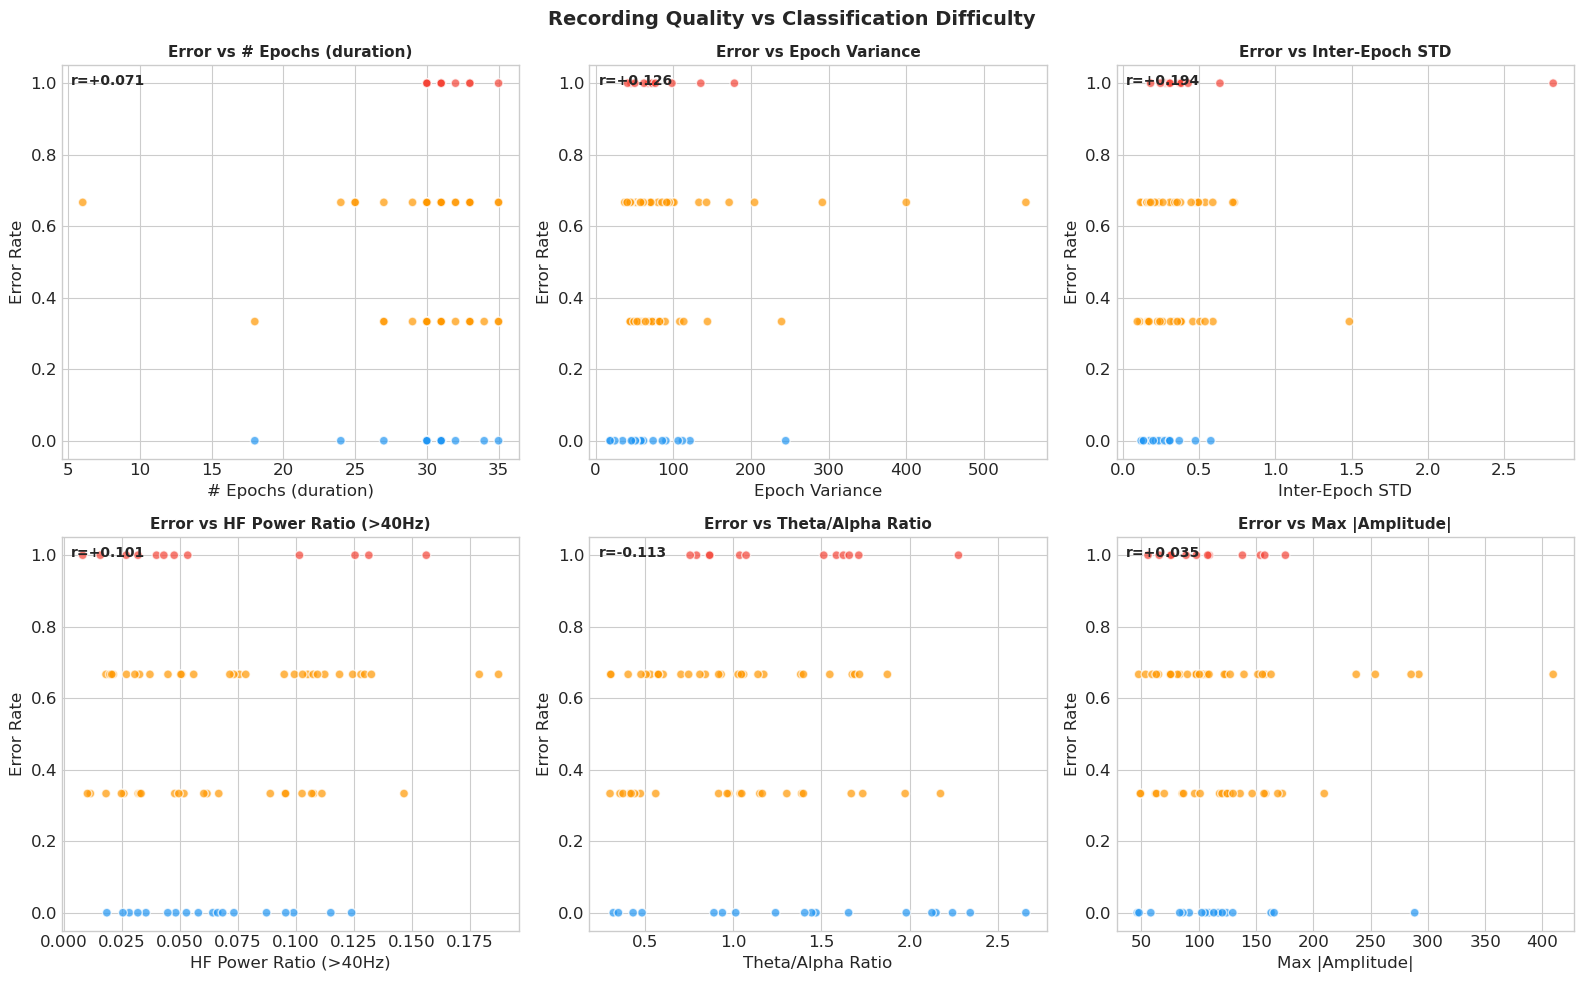

In [16]:
# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_cols = ['n_epochs', 'epoch_var', 'inter_epoch_std', 
             'hf_power_ratio', 'tar', 'max_abs']
titles = ['# Epochs (duration)', 'Epoch Variance', 'Inter-Epoch STD',
          'HF Power Ratio (>40Hz)', 'Theta/Alpha Ratio', 'Max |Amplitude|']

for ax, col, title in zip(axes.flat, plot_cols, titles):
    if col not in merged.columns:
        continue
    colors = ['#2196F3' if e <= 0.3 else '#F44336' if e >= 0.7 else '#FF9800' 
              for e in merged['error_rate']]
    ax.scatter(merged[col], merged['error_rate'], c=colors, alpha=0.7, s=40, edgecolors='white')
    ax.set_xlabel(title)
    ax.set_ylabel('Error Rate')
    ax.set_title(f'Error vs {title}', fontsize=11, fontweight='bold')
    
    # Add correlation
    r = merged['error_rate'].corr(merged[col])
    ax.annotate(f'r={r:+.3f}', xy=(0.02, 0.95), xycoords='axes fraction',
                fontsize=10, fontweight='bold')

fig.suptitle('Recording Quality vs Classification Difficulty', fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'quality_vs_error.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 5. Per-subject analysis

=== Per-Subject Error Rate ===


,error_rate,y_true,n_epochs,epoch_var,hf_power_ratio,tar,n_recordings
patient_id,,,,,,,
2,1.000000,0,31.333333,73.503693,0.054264,1.331220,6
5,0.857143,0,30.428571,72.157700,0.098580,1.255288,7
14,0.833333,0,31.000000,134.298218,0.013188,0.995171,2
18,0.666667,0,26.800000,92.481850,0.049912,0.794320,5
17,0.666667,1,30.600000,59.267189,0.037771,1.197597,5
3,0.583333,1,29.750000,229.905670,0.106320,0.940161,8
13,0.466667,0,31.200000,112.008835,0.071403,0.755429,5
8,0.466667,0,31.000000,82.103325,0.116535,0.971616,5
11,0.444444,1,31.666667,55.396267,0.045072,1.078826,3


Saved: results/fm_diagnosis/per_subject_error.png


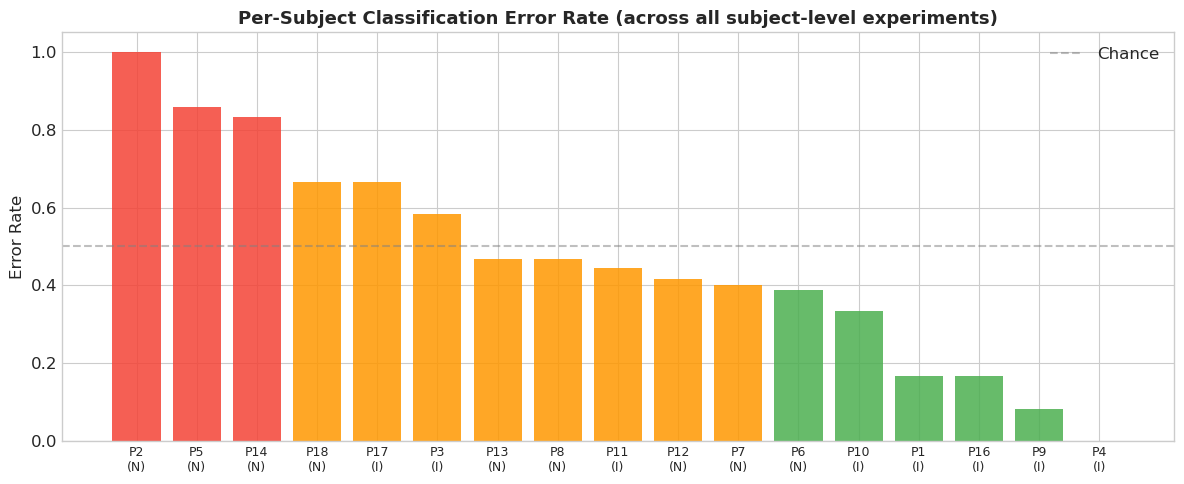

In [17]:
# Per-subject error rate
subj_stats = merged.groupby('patient_id').agg({
    'error_rate': 'mean',
    'y_true': 'first',
    'n_epochs': 'mean',
    'epoch_var': 'mean',
    'hf_power_ratio': 'mean',
    'tar': 'mean',
    'cache_name': 'count',
}).rename(columns={'cache_name': 'n_recordings'})

subj_stats = subj_stats.sort_values('error_rate', ascending=False)

print("=== Per-Subject Error Rate ===")
display(subj_stats)

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#F44336' if r >= 0.7 else '#FF9800' if r >= 0.4 else '#4CAF50' 
          for r in subj_stats['error_rate']]
bars = ax.bar(range(len(subj_stats)), subj_stats['error_rate'], color=colors, alpha=0.85)

ax.set_xticks(range(len(subj_stats)))
ax.set_xticklabels([f"P{int(pid)}\n({'I' if lab==1 else 'N'})" 
                     for pid, lab in zip(subj_stats.index, subj_stats['y_true'])],
                    fontsize=9)
ax.set_ylabel('Error Rate', fontsize=12)
ax.set_title('Per-Subject Classification Error Rate (across all subject-level experiments)',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Chance')
ax.legend()

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'per_subject_error.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 6. Summary: Candidate recordings for exclusion

In [18]:
# Recordings that are always wrong AND have quality issues
print("=== Candidate Recordings for Quality-Based Exclusion ===")
print("(Always misclassified AND abnormal quality metrics)\n")

# Define quality thresholds
var_threshold = qdf['epoch_var'].quantile(0.9)  # top 10% variance = noisy
hf_threshold = qdf['hf_power_ratio'].quantile(0.9)  # top 10% HF = artifacts
max_threshold = qdf['max_abs'].quantile(0.9)  # top 10% amplitude = clipping

print(f"Thresholds (90th percentile):")
print(f"  epoch_var > {var_threshold:.4f}")
print(f"  hf_power_ratio > {hf_threshold:.4f}")
print(f"  max_abs > {max_threshold:.2f}")

if 'epoch_var' in merged.columns:
    candidates = merged[
        (merged['error_rate'] >= 0.7) & 
        ((merged['epoch_var'] > var_threshold) | 
         (merged['hf_power_ratio'] > hf_threshold) |
         (merged['max_abs'] > max_threshold))
    ]
    
    print(f"\n{len(candidates)} recordings meet both criteria:")
    display(candidates[['patient_id', 'y_true', 'error_rate', 'n_epochs',
                         'epoch_var', 'hf_power_ratio', 'max_abs', 'cache_name']])
else:
    print("Merge failed — check dataset alignment")

# Save full analysis
save_path = os.path.join(SAVE_DIR, 'recording_quality_analysis.csv')
merged.to_csv(save_path, index=False)
print(f'\nFull analysis saved: {save_path}')

=== Candidate Recordings for Quality-Based Exclusion ===
(Always misclassified AND abnormal quality metrics)

Thresholds (90th percentile):
  epoch_var > 143.9177
  hf_power_ratio > 0.1255
  max_abs > 172.67

4 recordings meet both criteria:


,patient_id,y_true,error_rate,n_epochs,epoch_var,hf_power_ratio,max_abs,cache_name
24,14,0,1.0,33,178.745148,0.008167,175.772202,normal_p02_12_nnone.pt
57,2,0,1.0,35,98.250092,0.125590,153.944656,normal_p08_51_nnone.pt
70,5,0,1.0,32,50.502632,0.131540,109.330208,normal_p13_79_nnone.pt
71,5,0,1.0,30,135.405334,0.156312,157.706650,normal_p13_80_nnone.pt



Full analysis saved: results/fm_diagnosis/recording_quality_analysis.csv
